[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeos/geoai/blob/main/docs/workshops/GeoAI_Workshop_2025.ipynb)

# Object Detection from Remote Sensing Imagery with GeoAI

- 📓 **Notebook**: <https://opengeoai.org/workshops/GeoAI_Workshop_2025>  
- 💻 **GitHub**: <https://github.com/opengeos/geoai>

---

## 🧭 Introduction

This notebook provides hands-on materials for using the GeoAI package for object detection in remote sensing imagery.

## 🗂️ Agenda

The workshop will guide you through the full pipeline of GeoAI for object detection in remote sensing imagery, including:

- 📦 Package installation  
- ⬇️ Data download  
- 🖼️ Data visualization  
- 🧠 Model training  
- 🔍 Model inference  
- 🛠️ Post-processing  
- 🌐 Real-world applications  

## ⚙️ Prerequisites

- A Google Colab account (recommended for ease of setup)
- Basic familiarity with Python and geospatial data

## 📦 Package installation

You can install the required packages using either `conda` or `pip`:

### Option 1: Using Conda (recommended for local environments)

```bash
conda create -n geoai python=3.12
conda activate geoai
conda install -c conda-forge mamba
mamba install -c conda-forge geoai
```

### Option 2: Using pip (for Colab or quick installation)

In [1]:
conda create -n geoai python=3.12
conda activate geoai
conda install -c conda-forge mamba
mamba install -c conda-forge geoai

SyntaxError: invalid syntax (491687637.py, line 1)

In [2]:
pip install geoai-py overturemaps

Note: you may need to restart the kernel to use updated packages.


## ⬇️ Data download

### Import library

In [1]:
import os
import geoai

### Retrieve collections

Get all STAC collections from [Microsoft Planetary Computer](https://planetarycomputer.microsoft.com/catalog).

In [ ]:
collections = geoai.pc_collection_list()
collections

### Search NAIP imagery

In [ ]:
m = geoai.LeafMap(center=[47.653010, -117.592167], zoom=16)
m

In [ ]:
bbox = m.user_roi_bounds()
if bbox is None:
    bbox = [-117.6021, 47.6502, -117.5824, 47.6559]

In [ ]:
items = geoai.pc_stac_search(
    collection="naip",
    bbox=bbox,
    time_range="2013-01-01/2024-12-31",
)

In [ ]:
items

In [ ]:
items[0]

### Visualize NAIP imagery

In [ ]:
geoai.pc_item_asset_list(items[0])

In [ ]:
geoai.view_pc_item(item=items[0])

### Download NAIP imagery

In [ ]:
downloaded = geoai.pc_stac_download(
    items[0], output_dir="data", assets=["image", "thumbnail"]
)

In [ ]:
items[0]

### Search Landsat data

In [ ]:
items = geoai.pc_stac_search(
    collection="landsat-c2-l2",
    bbox=bbox,
    time_range="2023-07-01/2023-07-15",
    query={"eo:cloud_cover": {"lt": 1}},
    max_items=10,
)

In [ ]:
items

In [ ]:
items[0]

### Visualize Landsat data

In [ ]:
geoai.pc_item_asset_list(items[0])

In [ ]:
geoai.view_pc_item(item=items[0], assets=["red", "green", "blue"])

In [ ]:
geoai.view_pc_item(item=items[0], assets=["nir08", "red", "green"])

In [ ]:
geoai.view_pc_item(
    item=items[0],
    expression="(nir08-red)/(nir08+red)",
    rescale="-1,1",
    colormap_name="greens",
    name="NDVI Green",
)

### Download Landsat data

In [ ]:
geoai.pc_stac_download(
    items[0], output_dir="data", assets=["nir08", "red", "green", "blue"], max_workers=1
)

### Download building data

In [ ]:
buildings_gdf = geoai.get_overture_data(
    overture_type="building",
    bbox=bbox,
    output="data/buildings.geojson",
)

In [ ]:
buildings_gdf.head()

### Extract building statistics

In [ ]:
stats = geoai.extract_building_stats(buildings_gdf)
print(stats)

## 🖼️ Data Visualization

### Download sample datasets from [Hugging Face](https://huggingface.co/datasets/giswqs/geospatial/tree/main)

In [2]:
!nvidia-smi

import torch

print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Thu Feb  5 15:58:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.74                 Driver Version: 591.74         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2050      WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   41C    P8              2W /   50W |      10MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [3]:
url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/naip_rgb_train_tiles.zip"
download_dir = geoai.download_file(url)

Extracted to: naip_rgb_train_tiles


In [4]:
data_dir = os.listdir(f"data")

print("Images:")
for f in sorted(os.listdir(f"{data_dir}/images")):
    print(f"  - {f}")

print("\nMasks (single file):")
for f in sorted(os.listdir(f"{data_dir}/masks1")):
    print(f"  - {f}")

print("\nMasks (multiple files):")
for f in sorted(os.listdir(f"{data_dir}/masks2")):
    print(f"  - {f}")

Images:


FileNotFoundError: [WinError 3] The system cannot find the path specified: "['mask2', 'test']/images"

In [5]:
data_dir = "c:/Users/zhrfa/Documents/AI projects"  # or "data" if relative


In [27]:
train_raster_url = f"{data_dir}/images/id_45.tif"
train_vector_url = f"{data_dir}/mask2/id_45.geojson"
test_raster_url = f"{data_dir}/test/test2.tif"

In [28]:
train_raster_path = "images/id_45.tif"
train_vector_path = "mask2/id_45.geojson"
test_raster_path = "test/test2.tif"


### View metadata

===== RASTER INFORMATION: images/id_45.tif =====
Driver: GTiff
Dimensions: 1429 x 1428 pixels
Number of bands: 3
Data type: uint8
Coordinate Reference System: EPSG:32647
Georeferenced Bounds: BoundingBox(left=828831.9, bottom=300712.9, right=829832.2, top=301712.5)
Pixel Resolution: 0.6999999999999511, 0.6999999999999837
NoData Value: 0.0

----- Band Statistics -----
Band 1:
  Min: 1.00
  Max: 255.00
  Mean: 136.52
  Std Dev: 31.62
Band 2:
  Min: 1.00
  Max: 255.00
  Mean: 145.02
  Std Dev: 20.77
Band 3:
  Min: 1.00
  Max: 254.00
  Mean: 140.85
  Std Dev: 21.27


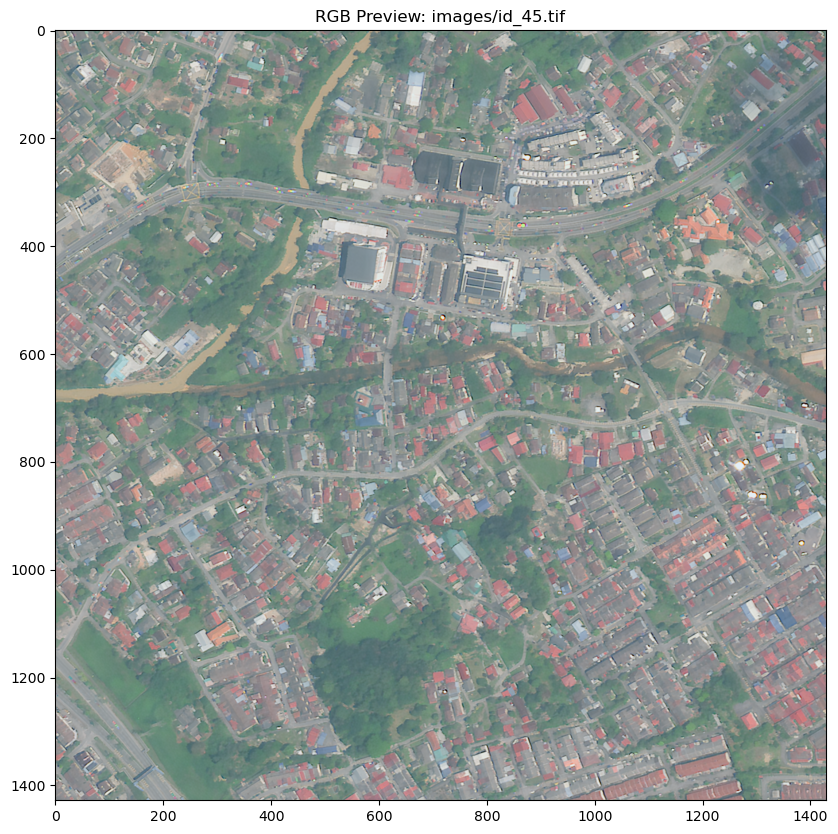

In [8]:
geoai.print_raster_info(train_raster_path, figsize=(18, 10))

===== VECTOR INFORMATION: mask2/id_45.geojson =====
Driver: GEOJSON
Feature count: 698
Geometry types: {'MultiPolygon': 698}
Coordinate Reference System: EPSG:4326
Bounds: [101.95710069997132, 2.71698722574069, 101.96609918137452, 2.726001433164981]
Number of attributes: 9
Attribute names: fid, latitude, longitude, area_in_meters, confidence, full_plus_code, fid_2, id, Status

----- Attribute Statistics -----
Attribute: fid
  min: 62054
  max: 66498
  mean: 66129.6203
  std: 263.6375
  null_count: 0
Attribute: latitude
  min: 2.7207
  max: 2.7207
  mean: 2.7207
  std: nan
  null_count: 697
Attribute: longitude
  min: 101.9622
  max: 101.9622
  mean: 101.9622
  std: nan
  null_count: 697
Attribute: area_in_meters
  min: 41.1736
  max: 41.1736
  mean: 41.1736
  std: nan
  null_count: 697
Attribute: confidence
  min: 0.8878
  max: 0.8878
  mean: 0.8878
  std: nan
  null_count: 697
Attribute: fid_2
  min: 71.0000
  max: 71.0000
  mean: 71.0000
  std: nan
  null_count: 697
Attribute: id
  m

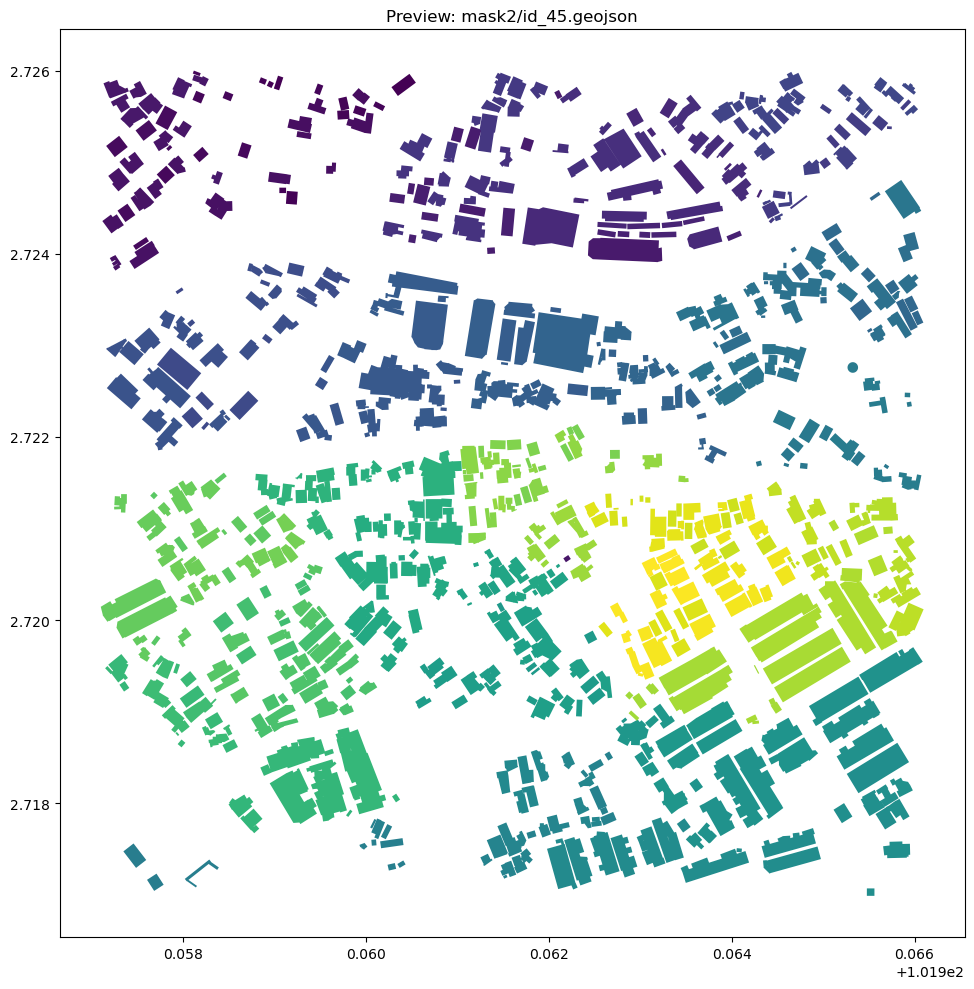

In [9]:
geoai.print_vector_info(train_vector_path, figsize=(18, 10))

### Interactive visualization

In [10]:
geoai.view_vector_interactive(train_vector_path, tiles=train_raster_url)

In [12]:
geoai.view_vector_interactive(
    train_vector_path,
    style_kwds={"color": "red", "fillOpacity": 0},
    tiles=train_raster_url,
)

In [13]:
geoai.view_vector_interactive(train_vector_path, tiles="Satellite")

In [19]:
geoai.view_raster(test_raster_path)

OSError: Path does not exist: c:\Users\zhrfa\Documents\AI projects\test\test1.tif

## 🧠 Model training

### Create training data

In [20]:
out_folder = "output"
tiles = geoai.export_geotiff_tiles(
    in_raster=train_raster_path,
    out_folder=out_folder,
    in_class_data=train_vector_path,
    tile_size=512,
    stride=256,
    buffer_radius=0,
)


Raster info for images/id_45.tif:
  CRS: EPSG:32647
  Dimensions: 1429 x 1428
  Resolution: (0.6999999999999511, 0.6999999999999837)
  Bands: 3
  Bounds: BoundingBox(left=828831.9, bottom=300712.9, right=829832.2, top=301712.5)
Loaded 698 features from mask2/id_45.geojson
Vector CRS: EPSG:4326
Reprojecting features from EPSG:4326 to EPSG:32647


Generated: 25, With features: 25: 100%|██████████| 25/25 [00:19<00:00,  1.28it/s]


------- Export Summary -------
Total tiles exported: 25
Tiles with features: 25 (100.0%)
Average feature pixels per tile: 79907.7
Output saved to: output

------- Georeference Verification -------


### Train object detection model

In [21]:
geoai.train_MaskRCNN_model(
    images_dir=f"{out_folder}/images",
    labels_dir=f"{out_folder}/labels",
    output_dir=f"{out_folder}/models",
    num_channels=3,
    pretrained=True,
    batch_size=4,
    num_epochs=10,
    learning_rate=0.005,
    val_split=0.2,
)

Using device: cuda
Found 25 image files and 25 label files
Training on 20 images, validating on 5 images
Epoch: 0, Batch: 0/5, Loss: 6.0937, Time: 83.14s
Epoch 1/10: Train Loss: 3.4930, Val Loss: inf, Val IoU: 0.3835
Saving best model with IoU: 0.3835
Epoch: 1, Batch: 0/5, Loss: 2.2719, Time: 58.13s
Epoch 2/10: Train Loss: 2.2443, Val Loss: inf, Val IoU: 0.4546
Saving best model with IoU: 0.4546
Epoch: 2, Batch: 0/5, Loss: 2.1100, Time: 66.88s
Epoch 3/10: Train Loss: 2.1193, Val Loss: inf, Val IoU: 0.4848
Saving best model with IoU: 0.4848
Epoch: 3, Batch: 0/5, Loss: 1.9765, Time: 68.32s
Epoch 4/10: Train Loss: 2.0088, Val Loss: inf, Val IoU: 0.5658
Saving best model with IoU: 0.5658
Epoch: 4, Batch: 0/5, Loss: 1.9282, Time: 63.64s
Epoch 5/10: Train Loss: 1.8847, Val Loss: inf, Val IoU: 0.6090
Saving best model with IoU: 0.6090
Epoch: 5, Batch: 0/5, Loss: 1.8809, Time: 74.91s
Epoch 6/10: Train Loss: 1.7975, Val Loss: inf, Val IoU: 0.6381
Saving best model with IoU: 0.6381
Epoch: 6, Bat

## 🔍 Model inference

In [22]:
masks_path = "naip_test_prediction.tif"
model_path = f"{out_folder}/models/best_model.pth"

In [29]:
geoai.object_detection(
    test_raster_path,
    masks_path,
    model_path,
    window_size=512,
    overlap=256,
    confidence_threshold=0.5,
    batch_size=4,
    num_channels=3,
)

Processing 25 windows with size 512x512 and overlap 256...


36it [00:27,  1.33it/s]                        

Inference completed in 27.12 seconds
Saved prediction to naip_test_prediction.tif


## 🛠️ Post-processing

### Raster to vector conversion

In [30]:
output_path = "naip_test_prediction.geojson"
buildings_gdf = geoai.raster_to_vector(masks_path, output_path)
buildings_gdf

Vectorized data saved to naip_test_prediction.geojson


,geometry,class
0,"POLYGON ((827007 301711.8, 827007 301709, 8270...",1
1,"POLYGON ((827478.1 301706.9, 827478.1 301706.2...",1
2,"POLYGON ((827650.3 301689.4, 827650.3 301688.7...",1
3,"POLYGON ((826857.2 301711.8, 826857.2 301704.1...",1
4,"POLYGON ((826992.3 301698.5, 826992.3 301697.8...",1
...,...,...
246,"POLYGON ((827676.2 300736.7, 827676.2 300736, ...",1
247,"POLYGON ((827385 300749.3, 827385 300748.6, 82...",1
248,"POLYGON ((827440.3 300744.4, 827440.3 300743.7...",1
249,"POLYGON ((827651 300729.7, 827651 300729, 8276...",1


In [35]:
geoai.view_vector_interactive(buildings_gdf, tiles=test_raster_url)

### Building regularization

In [33]:
regularized_gdf = geoai.regularize(
    data=buildings_gdf,
    simplify_tolerance=2.0,
    allow_45_degree=True,
    diagonal_threshold_reduction=30,
    allow_circles=True,
    circle_threshold=0.9,
)

In [34]:
geoai.view_vector_interactive(regularized_gdf, tiles=test_raster_url)

In [ ]:
geoai.create_split_map(
    left_layer=regularized_gdf,
    right_layer=test_raster_url,
    left_label="Regularized Buildings",
    right_label="NAIP Imagery",
    left_args={"style": {"color": "red", "fillOpacity": 0.3}},
    basemap=test_raster_url,
)

### Result comparison

In [ ]:
m = geoai.LeafMap()
m.add_cog_layer(test_raster_url, name="NAIP")
m.add_gdf(
    buildings_gdf,
    style={"color": "yellow", "fillOpacity": 0},
    layer_name="Original",
    info_mode=None,
)
m.add_gdf(
    regularized_gdf,
    style={"color": "red", "fillOpacity": 0},
    layer_name="Regularized",
    info_mode=None,
)
legend = {
    "Original": "#ffff00",
    "Regularized": "#ff0000",
}
m.add_legend(title="Building Footprints", legend_dict=legend)
m

### Calculate geometric properties

In [ ]:
props_gdf = geoai.add_geometric_properties(
    regularized_gdf, area_unit="m2", length_unit="m"
)
props_gdf.head()

In [ ]:
geoai.view_vector_interactive(props_gdf, column="area_m2", tiles=test_raster_url)

### Save results

In [ ]:
props_gdf.to_file("naip_test_buildings.geojson")

## 🌐 Real-world applications  

The section demonstrates how to apply [pre-trained models](https://huggingface.co/giswqs/geoai/tree/main) to real-world scenarios.


### Building footprint extraction

In [ ]:
test_raster_url = (
    "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/naip_test.tif"
)

In [ ]:
test_raster_path = geoai.download_file(test_raster_url)

In [ ]:
geoai.view_raster(test_raster_url)

In [ ]:
masks_path = "buildings_prediction.tif"
geoai.object_detection(
    test_raster_path,
    masks_path,
    model_path="building_footprints_usa.pth",
    window_size=512,
    overlap=256,
    confidence_threshold=0.5,
    batch_size=4,
    num_channels=3,
)

In [ ]:
output_path = "buildings_prediction.geojson"
buildings_gdf = geoai.raster_to_vector(masks_path, output_path)
regularized_gdf = geoai.regularize(
    data=buildings_gdf,
    simplify_tolerance=2.0,
    allow_45_degree=True,
    diagonal_threshold_reduction=30,
    allow_circles=True,
    circle_threshold=0.9,
)
props_gdf = geoai.add_geometric_properties(
    regularized_gdf, area_unit="m2", length_unit="m"
)

In [ ]:
geoai.view_vector_interactive(props_gdf, tiles=test_raster_url)

### Solar panel detection

In [ ]:
test_raster_url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/solar_panels_davis_ca.tif"
test_raster_path = geoai.download_file(test_raster_url)

In [ ]:
geoai.view_raster(test_raster_url)

In [ ]:
masks_path = "solar_panels_prediction.tif"
geoai.object_detection(
    test_raster_path,
    masks_path,
    model_path="solar_panel_detection.pth",
    window_size=400,
    overlap=100,
    confidence_threshold=0.4,
    batch_size=4,
    num_channels=3,
)

In [ ]:
output_path = "solar_panels_prediction.geojson"
regularized_gdf = geoai.orthogonalize(masks_path, output_path, epsilon=2)
props_gdf = geoai.add_geometric_properties(
    regularized_gdf, area_unit="m2", length_unit="m"
)

In [ ]:
geoai.view_vector_interactive(props_gdf, tiles=test_raster_url)

### Car detection

In [ ]:
test_raster_url = (
    "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/cars_test_7cm.tif"
)
test_raster_path = geoai.download_file(test_raster_url)

In [ ]:
geoai.view_raster(test_raster_url)

In [ ]:
masks_path = "cars_prediction.tif"
geoai.object_detection(
    test_raster_path,
    masks_path,
    model_path="car_detection_usa.pth",
    window_size=512,
    overlap=256,
    confidence_threshold=0.5,
    batch_size=4,
    num_channels=3,
)

In [ ]:
output_path = "cars_prediction.geojson"
gdf = geoai.orthogonalize(masks_path, output_path, epsilon=2)

In [ ]:
geoai.view_vector_interactive(output_path, tiles=test_raster_url)

In [ ]:
geoai.create_split_map(
    left_layer=output_path,
    right_layer=test_raster_url,
    left_args={"style": {"color": "red", "fillOpacity": 0.2}},
    basemap=test_raster_url,
)

### Ship detection

In [ ]:
test_raster_url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/ships_sfo_test_15cm.tif"
test_raster_path = geoai.download_file(test_raster_url)

In [ ]:
geoai.view_raster(test_raster_url)

In [ ]:
masks_path = "ship_prediction.tif"
geoai.object_detection(
    test_raster_path,
    masks_path,
    model_path="ship_detection.pth",
    window_size=512,
    overlap=256,
    confidence_threshold=0.5,
    batch_size=4,
    num_channels=3,
)

In [ ]:
output_path = "ship_prediction.geojson"
gdf = geoai.raster_to_vector(masks_path, output_path)

In [ ]:
geoai.view_vector_interactive(output_path, tiles=test_raster_url)

### Surface water mapping

In [ ]:
test_raster_url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/naip/naip_water_test.tif"
test_raster_path = geoai.download_file(test_raster_url)

In [ ]:
geoai.view_raster(test_raster_url)

In [ ]:
masks_path = "water_prediction.tif"
geoai.object_detection(
    test_raster_path,
    masks_path,
    model_path="water_detection.pth",
    window_size=512,
    overlap=128,
    confidence_threshold=0.3,
    batch_size=4,
    num_channels=4,
)

In [ ]:
output_path = "water_prediction.geojson"
gdf = geoai.raster_to_vector(
    masks_path, output_path, min_area=1000, simplify_tolerance=1
)
gdf = geoai.add_geometric_properties(gdf)

In [ ]:
geoai.view_vector_interactive(gdf, tiles=test_raster_url)

In [ ]:
geoai.create_split_map(
    left_layer=gdf,
    right_layer=test_raster_url,
    left_args={"style": {"color": "red", "fillOpacity": 0.4}},
    basemap=test_raster_url,
)

### Wetland mapping

In [ ]:
test_raster_url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/naip/m_4609932_nw_14_1_20100629.tif"
test_raster_path = geoai.download_file(test_raster_url)

In [ ]:
geoai.view_raster(test_raster_url)

In [ ]:
geoai.object_detection(
    test_raster_path,
    masks_path,
    model_path="wetland_detection.pth",
    window_size=512,
    overlap=256,
    confidence_threshold=0.3,
    batch_size=4,
    num_channels=4,
)

In [ ]:
output_path = "wetland_prediction.geojson"
gdf = geoai.raster_to_vector(
    masks_path, output_path, min_area=1000, simplify_tolerance=1
)
gdf = geoai.add_geometric_properties(gdf)

In [ ]:
geoai.view_vector_interactive(gdf, tiles=test_raster_url)

In [ ]:
geoai.create_split_map(
    left_layer=gdf,
    right_layer=test_raster_url,
    left_args={"style": {"color": "red", "fillOpacity": 0.4}},
    basemap=test_raster_url,
)